> **Recommended: run this notebook in Google Colab, nothing to install.**
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-run-a-simple-case.ipynb)
>
> Just click on the "Open in Colab" button and follow along. Click the ▶ button on each cell (or press Shift+Enter) to see the results and move on to the next one.
>
> The documentation website shows pre-run results you can check if you don't want to or can't use Colab.

# Session 1: Run a simple case

Keep in mind that some of the data have been completely invented for the purpose of this exercise (so please do not create your own trade route based on this example).

We look at how Navigate would model the decisions of the shipowners and operators serving a line between San Antonio and Rotterdam, in a world getting towards decarbonisation: green fuels are starting to be produced at scale, technology options for engines and retrofits are available, and regulations incentivizing the use of green fuels are in place.

## The case


![Map of the Chile to Rotterdam copper trade: the two bunker ports, a fleet of ships on the voyage via the Panama Canal, and the fuel production sites in Patagonia and southern Sweden, both of which make e-methanol and e-ammonia, with bio-methanol in Sweden as well](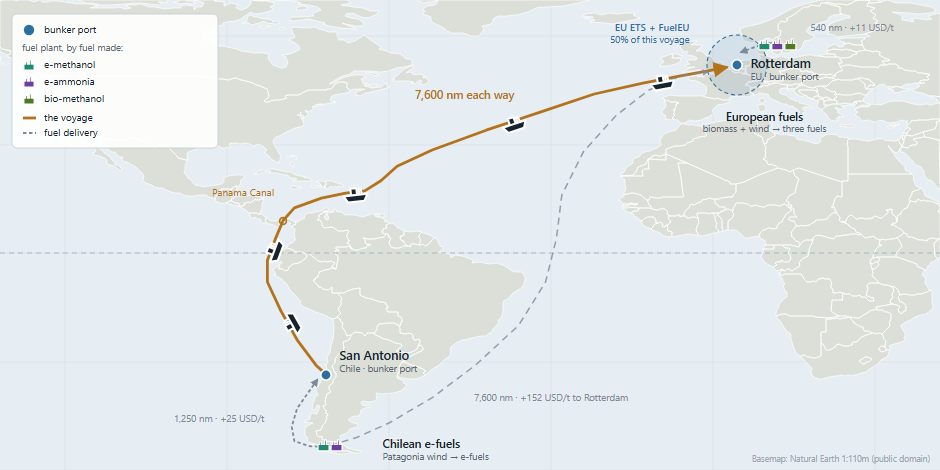)

*San Antonio to Rotterdam via the Panama Canal: the two bunker ports, the
voyage, and the possible fuel plants.*

The case follows the Panamax bulk carriers (~80,000 DWT) that carry copper concentrate
from **San Antonio, Chile** to **Rotterdam**, roughly 7,600 nautical miles each way via the Panama Canal, returning in ballast (empty).

It is 2026: the segment counts 300 ships, and every one of them burns fuel oil. The fleet is ageing and most of it has to be renewed before 2050, the horizon of the simulation.

The ships are also exposed to two regulations: FuelEU Maritime and the EU ETS, both of which cover half of the voyage.

Navigate does not follow one specific company. It represents the whole segment as a
single `Fleet`, whose decisions stand for those of the many shipowners and
operators in it. **Operators** decide which fuel to bunker and where, and how
fast to sail. **Owners** decide when to retrofit ships, order new ones and fit
efficiency measures.

Four ship designs are available on the market:

| Configuration | Burns |
|---|---|
| `ship_oil` | conventional fuel oil |
| `ship_lng` | dual-fuel LNG |
| `ship_methanol` | dual-fuel methanol |
| `ship_ammonia` | dual-fuel ammonia |

On the other side, we follow the behavior of two groups of fuel producers: producers of e-fuels (e-ammonia or e-methanol) and producers of biofuel (bio-methanol). The e-fuel plants can be installed in Chile or in Europe, the biofuel plants only in Europe (to simplify the case).

## What you'll do

**Run the case.** Solve it once, from 2026 to 2050.

**Read the results.** The fleet's emissions, the fuel it bunkers, and what moving the cargo costs.

**Sensitivity analysis.** Change some of the input parameters and see what happens.

How the deck is built, the data behind it and how the model reaches its answer are the subject of [Session 2](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-understand-navigate.ipynb).


## STEP 1: Setup

Run the cell below on Colab or locally to set up the Navigate model. It also loads the pre-made example that will be used to illustrate this part of the workshop.

In [1]:
# @title Setup
# Setup. Works both on Google Colab and in a local checkout of the repository.
import os
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")


# Load the example deck.
EXAMPLE = Path("simulations/examples/example_4")

# Fail loudly rather than printing an empty list. The setup above clones the
# branch named in BRANCH, so this deck is only here once it has been committed
# and pushed to that branch.
assert EXAMPLE.is_dir(), (
    f"{EXAMPLE} not found under {Path.cwd()}. On Colab the setup cell clones the "
    f"{BRANCH!r} branch, so this deck has to be committed and pushed there "
    "before the notebook can read it."
)


def show(path, first=None, grep=None, code_only=False):
    """Print a deck file: all of it, the first N lines, matching lines, or the
    command lines only (`code_only`, which drops the comments)."""
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    if code_only:
        print(f"# {Path(path).name}: command lines only, "
              f"open the file for the commentary")
        lines = [ln for ln in lines if ln.strip() and not ln.strip().startswith("#")]
    if grep:
        lines = [ln for ln in lines if grep in ln]
    if first:
        lines = lines[:first]
    for ln in lines:
        print(ln)


deck = sorted(EXAMPLE.rglob("*.nav")) + sorted(EXAMPLE.rglob("*.inc"))
assert deck, f"no .nav or .inc files under {EXAMPLE.resolve()}"

Moved up to the repository root.
Navigate 1.0.0 is already installed.


## STEP 2: Run the case and see the results

Run the next cell to solve the case once, from 2026 to 2050. It takes about twenty seconds. The results that we are plotting for this example are:

- the fleet's well-to-wake emissions over time;
- the energy the fleet bunkers each year, by fuel. A dual-fuel ship that bunkers oil counts as oil here;
- the **instantaneous freight rate** on the fleet: what the trade cost in that year, given the fuel prices and compliance bills that actually materialised.

These numbers are calculated before any redistribution mechanisms of the collected taxes, which are currently not modelled in Navigate.


CPU times: total: 18.9 s
Wall time: 22.3 s
the reference, 2026-2050
  well-to-wake in 2026               5,935  kt CO2e/yr
  well-to-wake in 2050               2,753  kt CO2e/yr
  cumulative over the horizon      120,350  kt CO2e
  alternative fuels in 2050           52.7  %
  freight rate in 2050                4.56  USD per k cargo-mile


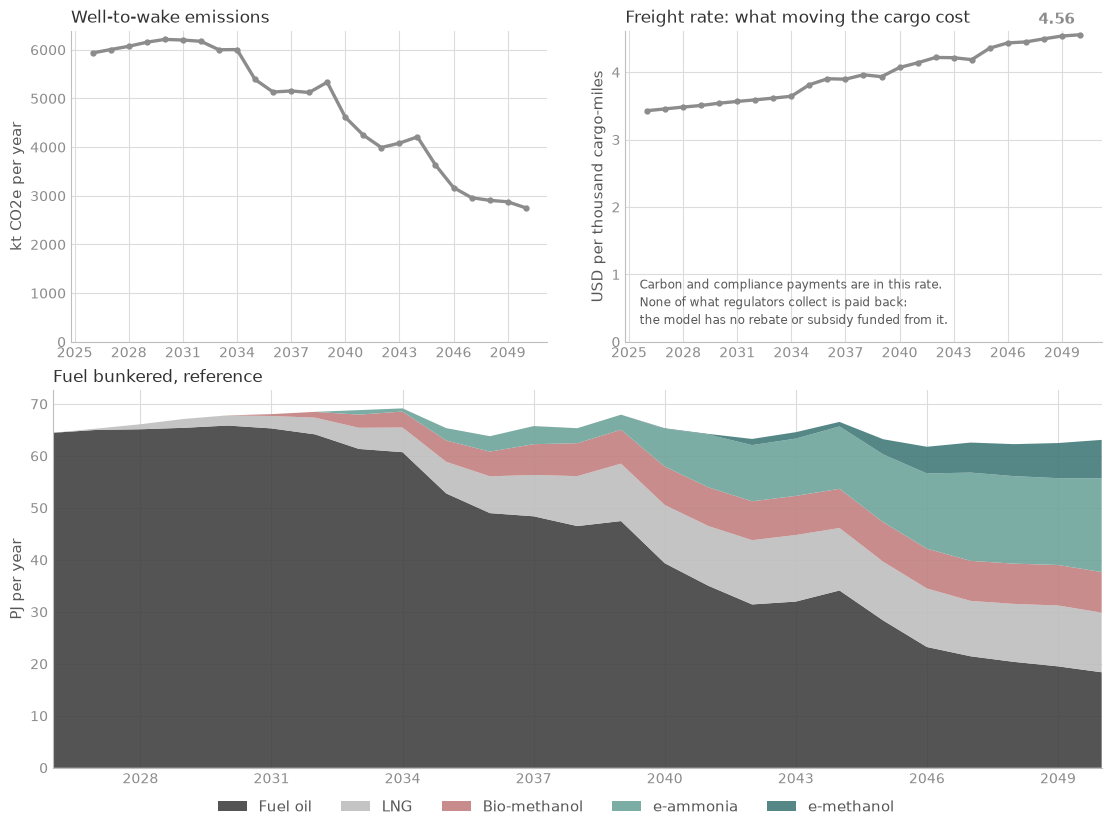

In [2]:
# @title Run the case and see the results
import argparse
import contextlib
import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from navigate.manager import SimulationManager

NAV = Path("simulations/examples/example_4/example_4.nav")
ARGS = argparse.Namespace(data_dir=Path("./assumptions"), solver=None)

# One house style for every figure in the workshop. It lives in
# docs/workshop/_style.py rather than in this cell, so that the notebooks
# cannot drift apart - which is exactly what had happened. The
# colours are Navigate's own, and that file explains the one thing about them
# that surprises people: the hue says how a fuel was MADE, not which molecule it
# is, so bio-methanol and e-methanol are deliberately different colours.
import sys

_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, GRID, INK, SUBINK, TICK, fuel_colour, fuel_label,
                    fuel_sorted, scen_colour)


def run_case(tweak=None, quiet=True):
    """Parse the deck, optionally modify it, solve it, return the manager."""
    m = SimulationManager()
    ctx = contextlib.redirect_stdout(io.StringIO()) if quiet else contextlib.nullcontext()
    with ctx:
        m.read_deck(NAV, ARGS)
        if tweak is not None:
            tweak(m)
        m.run()
    return m


def years_of(m):
    return m.get_dateline().astype("datetime64[Y]").astype(int) + 1970


# one solve, 2026 to 2050: the reference every sensitivity is compared with
%time base = run_case()
YEARS = years_of(base)


# ===========================================================================
#  The machinery for the sensitivity analysis. Nothing to edit here - the
#  levers are further down.
# ===========================================================================
def scale(forecast_name, factor):
    """Multiply a forecast by `factor`, keeping what the deck already set.

    set_multiplier REPLACES the Multiplier rather than compounding with it, and
    several library forecasts ship a non-unity one - fuel_eu_target_reduction
    is 91.16. Writing the factor straight in would not scale that limit, it
    would delete it.
    """
    def tweak(m):
        f = m.nodes.forecasts[forecast_name]
        f.set_multiplier(f.get_multiplier() * float(factor))
    return tweak

def both(*tweaks):
    """Apply several levers to one freshly parsed deck."""
    def tweak(m):
        for t in tweaks:
            t(m)
    return tweak

def penalty(factor):
    """Scale the FuelEU non-compliance penalty.

    The base value is the library's own Variable("fuel_eu_remedial_cost"),
    read off the parsed deck rather than hardcoded, so this lever follows the
    assumptions library if it is ever revised. It is a Variable and not a
    Forecast, which is why it needs its own helper rather than scale().
    """
    def tweak(m):
        base_cost = m.nodes.variables["fuel_eu_remedial_cost"].get()
        m.nodes.regulations["fuel_eu"].set_remedial_cost(base_cost * factor)
    return tweak

def chile_in_scope(m):
    """Put San Antonio inside both schemes.

    With both ends of the voyage in the jurisdiction it becomes an *intra*
    voyage, so IntraFraction = 1 applies and the whole trip is counted - the
    honest way to model full coverage, rather than editing InterFraction.
    """
    for r in ("eu_ets", "fuel_eu"):
        m.nodes.regulations[r].jurisdiction = [m.nodes.ports["rotterdam"],
                                               m.nodes.ports["san_antonio"]]

def without_new_technology(m):
    """Freeze efficiency where the fleet already is: nothing more gets fitted.

    BOTH limits are needed - the retrofit limit alone still lets a measure
    arrive on a newbuild. Measures with an initial share keep it, they just
    never grow.
    """
    fleet = m.nodes.fleets["copper_trade"]
    for technology in fleet.technologies:
        fleet.set_retrofit_technology_limit(technology.get_name(), 0.)
        fleet.set_newbuild_technology_limit(technology.get_name(), 0.)

TARGET = "fuel_eu_target_reduction"
FOSSIL = {"fossil_fuel_oil", "liquefied_natural_gas"}

def summarise(m):
    """One solve, read the way notebook 3 reads its fleets."""
    fleet = m.nodes.fleets["copper_trade"]
    years = years_of(m)
    wtw = np.nan_to_num(np.asarray(
        fleet.profile.get_total_equivalent_WTW(), dtype=float))

    energy, by_year = {}, {}
    for fuel, series in fleet.profile.get_consumed_energy().items():
        values = np.nan_to_num(np.asarray(series, dtype=float))
        if values.sum() <= 0:
            continue
        energy[fuel] = float(values.sum())
        by_year[fuel] = values
    grand = sum(energy.values())
    last_all = sum(float(v[-1]) for v in by_year.values())
    last_alt = sum(float(v[-1]) for f, v in by_year.items() if f not in FOSSIL)

    return {"years": years,
            "wtw": wtw / 1e3,                                  # kt CO2e per year
            "mix": {k: 100. * v / grand for k, v in energy.items()},
            # PJ per year, stacked in Navigate's own fuel order
            "by_year": {f: by_year[f] / 1e6 for f in fuel_sorted(by_year)},
            # USD per THOUSAND cargo-miles, as everywhere else in the workshop
            "freight": 1e3 * np.asarray(
                fleet.profile.get_instantaneous_freight_rate(), dtype=float),
            "alt_last": 100. * last_alt / last_all if last_all else 0.}


# `base` is the run above and is already solved, so the reference
# costs nothing here - only your scenario is re-solved, once, below.
ref = summarise(base)

print(f"the reference, {YEARS[0]}-{YEARS[-1]}")
for _label, _value, _unit in (
        (f"well-to-wake in {YEARS[0]}", f"{ref['wtw'][0]:,.0f}", "kt CO2e/yr"),
        (f"well-to-wake in {YEARS[-1]}", f"{ref['wtw'][-1]:,.0f}", "kt CO2e/yr"),
        ("cumulative over the horizon", f"{ref['wtw'].sum():,.0f}", "kt CO2e"),
        (f"alternative fuels in {YEARS[-1]}", f"{ref['alt_last']:.1f}", "%"),
        (f"freight rate in {YEARS[-1]}", f"{ref['freight'][-1]:,.2f}",
         "USD per k cargo-mile")):
    print(f"  {_label:30} {_value:>9}  {_unit}")


def plot_cases(cases):
    """Emissions, the fuel bunkered and the freight rate, one line or panel per case.

    `cases` maps a label ("reference", "your scenario") to what summarise()
    returns. The same figure shows the reference on its own and the
    comparison with your scenario. It is drawn at the width the page shows it,
    so the type stays readable: emissions and cost on top, the fuel mix below."""
    from matplotlib.ticker import MaxNLocator

    order = list(cases)
    TITLE, LABEL, TICK_SIZE = 12.5, 10.5, 10

    fig = plt.figure(figsize=(11, 8.2), constrained_layout=True)
    grid = fig.add_gridspec(2, len(order), height_ratios=[1, 1.05])
    # top row: emissions and cost, each half the width whatever the number of cases
    top_grid = grid[0, :].subgridspec(1, 2, wspace=0.08)
    axE = fig.add_subplot(top_grid[0, 0])
    axC = fig.add_subplot(top_grid[0, 1])
    # bottom row: one fuel-mix panel per case, on a shared scale so they read
    # against each other
    mix_axes = [fig.add_subplot(grid[1, 0])]
    mix_axes += [fig.add_subplot(grid[1, k], sharex=mix_axes[0], sharey=mix_axes[0])
                 for k in range(1, len(order))]

    for s in order:
        axE.plot(cases[s]["years"], cases[s]["wtw"], lw=2.4, marker=".", ms=7,
                 label=s, color=scen_colour(s))
    axE.set_title("Well-to-wake emissions", fontsize=TITLE, color=INK, loc="left")
    axE.set_ylabel("kt CO2e per year", fontsize=LABEL, color=SUBINK)
    axE.set_ylim(bottom=0.)
    if len(order) > 1:
        axE.legend(fontsize=LABEL, frameon=False, labelcolor=SUBINK, loc="lower left")

    # the two end labels land within a few cents of each other, so push the
    # lower series' label below its point rather than letting them overlap
    _high = max(order, key=lambda s: cases[s]["freight"][-1])
    for s in order:
        axC.plot(cases[s]["years"], cases[s]["freight"], lw=2.4, marker=".", ms=7,
                 label=s, color=scen_colour(s))
        axC.annotate(f"{cases[s]['freight'][-1]:,.2f}",
                     (cases[s]["years"][-1], cases[s]["freight"][-1]),
                     xytext=(-4, 8 if s == _high else -16),
                     textcoords="offset points", ha="right",
                     fontsize=LABEL, color=scen_colour(s), fontweight="bold")
    axC.set_title("Freight rate: what moving the cargo cost", fontsize=TITLE,
                  color=INK, loc="left")
    axC.set_ylabel("USD per thousand cargo-miles", fontsize=LABEL, color=SUBINK)
    axC.set_ylim(bottom=0.)
    # The rate carries what the fleet pays out and almost nothing it gets back:
    # Navigate has no rebate or subsidy funded from what a regulator collects,
    # so a scheme that recycled its revenue would sit lower than this.
    axC.text(.03, .04,
             "Carbon and compliance payments are in this rate." + chr(10)
             + "None of what regulators collect is paid back:" + chr(10)
             + "the model has no rebate or subsidy funded from it.",
             transform=axC.transAxes, fontsize=8.5, color=SUBINK,
             va="bottom", ha="left", linespacing=1.5)

    fuels = fuel_sorted({f for c in cases.values() for f in c["by_year"]})
    for ax, s in zip(mix_axes, order):
        stack = [cases[s]["by_year"].get(f, np.zeros(len(cases[s]["years"])))
                 for f in fuels]
        ax.stackplot(cases[s]["years"], *stack,
                     colors=[fuel_colour(f) for f in fuels],
                     labels=[fuel_label(f) for f in fuels], linewidth=0, alpha=.9)
        ax.set_title(f"Fuel bunkered, {s}", fontsize=TITLE, color=INK, loc="left")
        ax.margins(x=0)
    mix_axes[0].set_ylabel("PJ per year", fontsize=LABEL, color=SUBINK)
    fig.legend(*mix_axes[0].get_legend_handles_labels(), fontsize=LABEL,
               frameon=False, labelcolor=SUBINK, ncol=len(fuels),
               loc="outside lower center")

    for ax in (axE, axC, *mix_axes):
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(color=GRID, lw=.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=TICK_SIZE, length=0)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(AXIS)

    return fig


def run_your_scenario():
    """Solve the levers set in the YOUR SCENARIO cell and compare with the reference.

    Reads the lever names (OIL_PRICE ... FREEZE_EFFICIENCY) from the notebook
    when it is called, so the cell that sets them only has to call this.
    """
    MULTIPLIERS = [("OIL_PRICE", OIL_PRICE, "fossil_fuel_oil_price_global"),
                   ("GAS_PRICE", GAS_PRICE,
                    "liquefied_natural_gas_price_global"),
                   ("CARBON_PRICE", CARBON_PRICE, "eu_ets_carbon_credit_price"),
                   ("FUELEU_TARGET", FUELEU_TARGET, TARGET),
                   ("CHILEAN_POWER", CHILEAN_POWER, "electricity_cost_americas_mid"),
                   ("EUROPEAN_POWER", EUROPEAN_POWER, "electricity_cost_europe_mid"),
                   ("BIOMASS", BIOMASS,
                    "feedstock_biomethanol_gasification_availability"),
                   ("BIOGENIC_CO2", BIOGENIC_CO2, "carbon_dioxide_biogenic_availability"),
                   ("TRADE_GROWTH", TRADE_GROWTH, "trade_growth_bulk_carrier")]

    # Trade is compounded as log(1 + growth), so a year shrinking by 100 % or more has
    # no meaning - say so here rather than let the solve fail on it.
    _growth = base.nodes.forecasts["trade_growth_bulk_carrier"]
    if min(TRADE_GROWTH * _growth.calculate(_d) for _d in base.get_timeline()) <= -1.:
        raise ValueError(f"TRADE_GROWTH = {TRADE_GROWTH} would make trade shrink by 100 % "
                         "or more in a year. Pick a value closer to zero.")

    CHANGED = [(n, v) for n, v, _ in MULTIPLIERS if v != 1.0]
    TWEAKS = [scale(t, v) for n, v, t in MULTIPLIERS if v != 1.0]
    if FUELEU_PENALTY != 1.0:
        CHANGED.append(("FUELEU_PENALTY", FUELEU_PENALTY))
        TWEAKS.append(penalty(FUELEU_PENALTY))
    if FULL_COVERAGE:
        CHANGED.append(("FULL_COVERAGE", True))
        TWEAKS.append(chile_in_scope)
    if FREEZE_EFFICIENCY:
        CHANGED.append(("FREEZE_EFFICIENCY", True))
        TWEAKS.append(without_new_technology)

    if not TWEAKS:
        print("Every lever is still at its reference, so this would just re-solve it.")
        print("Change one of the numbers above and run this cell again.")
    else:
        print("solving your scenario:")
        for _name, _value in CHANGED:
            print(f"  {_name:16} {_value}")
        yours = run_case(both(*TWEAKS))
        you = summarise(yours)

        print(f"{chr(10)}  {'':32} {'reference':>11} {'yours':>11} {'change':>13}")
        for _label, _r, _y, _fmt, _pp in (
                (f"well-to-wake in {YEARS[-1]}, kt/yr",
                 ref["wtw"][-1], you["wtw"][-1], ",.0f", False),
                ("cumulative, kt", ref["wtw"].sum(), you["wtw"].sum(), ",.0f", False),
                # a share is already a percentage, so it moves in POINTS, not per cent
                (f"alternative fuels in {YEARS[-1]}, %",
                 ref["alt_last"], you["alt_last"], ".1f", True),
                (f"freight rate in {YEARS[-1]}, USD/k mile",
                 ref["freight"][-1], you["freight"][-1], ",.2f", False)):
            _change = (f"{_y - _r:+.1f} pp" if _pp
                       else f"{100. * (_y / _r - 1.):+.1f} %")
            print(f"  {_label:32} {_r:11{_fmt}} {_y:11{_fmt}} {_change:>13}")

        fig = plot_cases({"reference": ref, "your scenario": you})
        fig.suptitle("  " + ",  ".join(f"{n} x {v}" for n, v in CHANGED),
                     fontsize=11, color=SUBINK, x=0.01, ha="left")
        plt.show()

        print("what moved most, in percentage points of the fuel mix:")
        _delta = sorted(((you["mix"].get(f, 0.) - ref["mix"].get(f, 0.), f)
                         for f in set(ref["mix"]) | set(you["mix"])),
                        key=lambda d: -abs(d[0]))
        for _d, _f in _delta[:5]:
            print(f"  {fuel_label(_f):20} {_d:+6.1f} pp")


plot_cases({"reference": ref})
plt.show()


---

## STEP 3: Sensitivity analysis

Change some of the input values of the "reference scenario" to see what changes in the results.

All levers that we prepared can be changed with multipliers, except two that can be used as switches:

- **`FULL_COVERAGE`** puts San Antonio inside both regulatory schemes.
- **`FREEZE_EFFICIENCY`** stops anything further being fitted, on newbuilds as
  well as on retrofits.

**GAME**: Find out which scenario (realistic?) leads to the lowest emissions and transport costs by 2050!

solving your scenario:
  FUELEU_PENALTY   3.0



                                     reference       yours        change
  well-to-wake in 2050, kt/yr            2,753       1,876       -31.9 %
  cumulative, kt                       120,350     114,043        -5.2 %
  alternative fuels in 2050, %            52.7        68.1      +15.4 pp
  freight rate in 2050, USD/k mile        4.56        4.89        +7.4 %


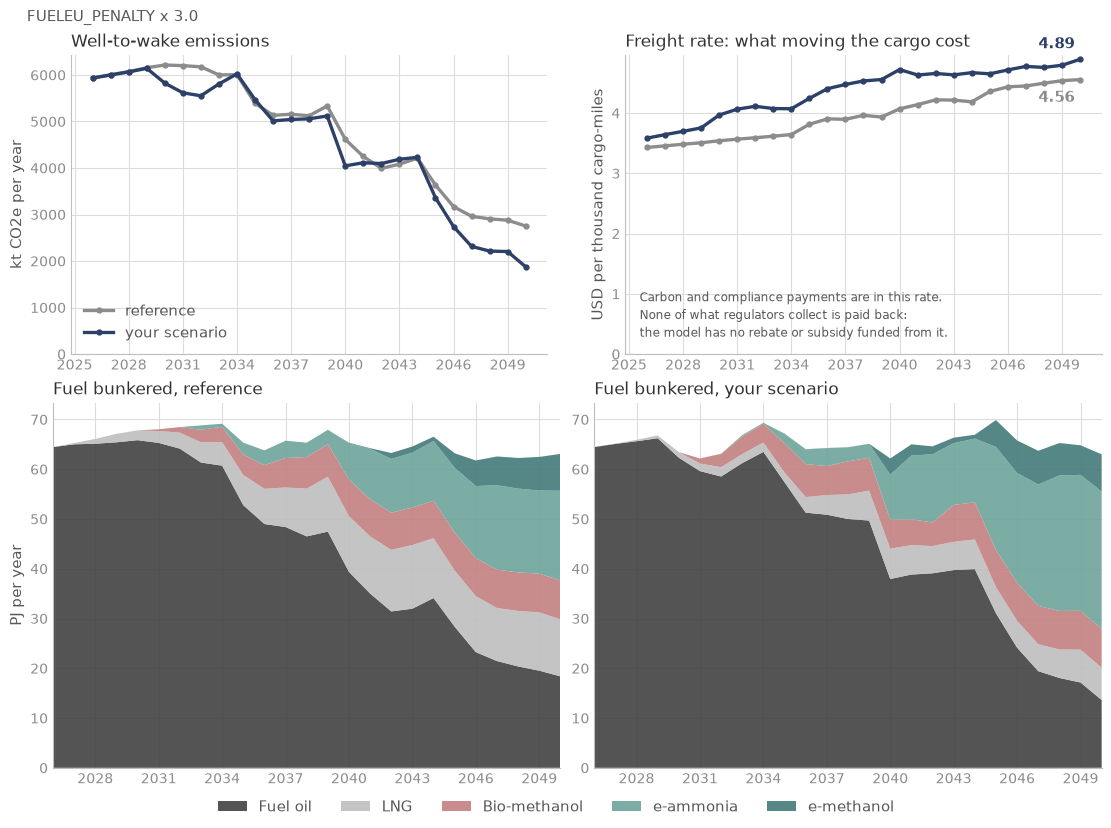

what moved most, in percentage points of the fuel mix:
  LNG                    -5.8 pp
  e-ammonia              +3.8 pp
  Fuel oil               +1.4 pp
  e-methanol             +0.6 pp
  Bio-methanol           +0.1 pp


In [3]:
# ===========================================================================
#  YOUR SCENARIO.  Set a lever, then run this cell: it solves your scenario
#  (about a minute) and compares it with the reference.
#
#  Every number down to TRADE_GROWTH is a MULTIPLIER on what the deck already
#  says, so 1.0 is the reference. The right-hand column says what each 1.0 is
#  worth, so you can judge whether a factor of two is a big change or a small
#  one.
#
#  As an example, FUELEU_PENALTY is set to 3.0: the FuelEU penalty tripled.
#  Set it back to 1.0 to start from the reference.
#
#                        suggested span   what 1.0 means in the deck
OIL_PRICE      = 1.0   #  0.7 - 1.6       485 USD/t, flat to 2050
GAS_PRICE      = 1.0   #  0.7 - 1.6       436 USD/t, flat to 2050
CARBON_PRICE   = 1.0   #  0.5 - 3.0       126 USD/t in 2026, 417 by 2050
FUELEU_TARGET  = 1.0   #  0.3 - 1.2       89.3 gCO2eq/MJ in 2026, 18.2 by 2050; under 1.0 is STRICTER
FUELEU_PENALTY = 3.0   #  1.0 - 5.0       760 USD/t of excess emission, flat
CHILEAN_POWER  = 1.0   #  0.6 - 1.4       62 USD/MWh in 2026, 41 by 2050
EUROPEAN_POWER = 1.0   #  0.6 - 1.4       72 USD/MWh in 2026, 53 by 2050
BIOMASS        = 1.0   #  0.1 - 10.0      1,152 Mt/yr pool in 2026, 1,361 by 2050; this ceiling BINDS
BIOGENIC_CO2   = 1.0   #  0.5 - 2.0       92 Mt/yr pool in 2026, 350 by 2050; binds from 2045, in 2 years
TRADE_GROWTH   = 1.0   #  0.0 - 2.0       2.2 %/yr in 2026, 1.4-1.5 %/yr from 2030
#                          1.0 = the deck's growth; 0.0 = trade stays at its 2026 volume;
#                         -1.0 = trade shrinks as fast as it would have grown

FULL_COVERAGE     = False   # San Antonio inside both schemes: the whole voyage counts
FREEZE_EFFICIENCY = False   # nothing further gets fitted, newbuild or retrofit

# ===========================================================================

run_your_scenario()


## Advanced sensitivities

The levers proposed in the previous section are just a simple example of what can be changed in the model.

Advanced sensitivities changing other parameters or personalized simulations can be done by:
- editing the deck in `simulations/examples/example_4/` itself (needs a [local installation](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/README.md#installation))
- building a new case from scratch as [Session 5](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb) describes (needs a [local installation](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/README.md#installation))
- you can also check out our [Horizon-zcs](https://github.com/zerocarbonshipping/horizon-zcs/tree/main) tool on GitHub for global sensitivity analysis (which is what we are using for our own analyses)

## Workshop sessions

**Next: [Session 2: Understand Navigate](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-understand-navigate.ipynb)**

Each link opens the notebook in Google Colab, in a fresh session, so run it
from the top.

1. **Run a simple case** (this session)
2. [Understand Navigate](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-understand-navigate.ipynb)
3. [Run a global case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-run-a-global-case.ipynb)
4. [Run our reference scenarios](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb)
5. [Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb) (you can read it in Colab; its prompts need Navigate installed on your own machine)